# Full Training Pipeline: SFT + GRPO with Qwen 0.5B

This notebook demonstrates the complete training pipeline for mathematical reasoning:

## Training Pipeline:
1. **Baseline Evaluation**: Test the base model before any training
2. **Supervised Fine-Tuning (SFT)**: Train on 500 high-quality CoT examples from reference notebook with standard cross-entropy loss
3. **SFT Evaluation**: Measure improvements after supervised training
4. **GRPO Training**: Load SFT checkpoint and apply reinforcement learning with Group Relative Policy Optimization on GSM8K training set
5. **GRPO Evaluation**: Measure final improvements
6. **Comparison**: Compare all three models (base, SFT, GRPO)

## Features:
- **High-quality CoT dataset**: 500 pre-generated reasoning chains from reference notebook (same as Andriy Burkov's GRPO example)
- **NO OVERLAP** between SFT and GRPO training data
- SFT trains on 500 CoT examples, GRPO trains on GSM8K train set
- Comprehensive evaluation at each stage
- Visualization of training metrics
- Checkpoint saving for reproducibility

## Data Splits:
- **SFT Training**: 500 high-quality CoT examples (downloaded from reference)
- **GRPO Training**: Full GSM8K training set (~7k examples)
- **Validation**: 1000 examples (test[200:1200]) - shared
- **Test**: 200 examples (test[:200]) - shared

## 1. Imports and Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Import SFT and GRPO
from simple_rl.algorithms import SFT, GRPO

# Import evaluation utilities
from simple_rl.evaluation.gsm8k import (
    load_gsm8k_dataset,
    prepare_gsm8k_prompts,
    prepare_gsm8k_for_sft,
    evaluate_on_gsm8k,
    demonstrate_model_responses
)

# Import reward functions
from simple_rl.rewards import (
    extract_answer_from_model_output,
    compute_math_rewards_batch,
)

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device detection
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    torch.mps.manual_seed(42)
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


## 2. Configuration

In [2]:
# Model configuration
MODEL_NAME =  "Qwen/Qwen2.5-0.5B-Instruct"

# System prompt for math formatting
SYSTEM_PROMPT = """
Respond in the following format:

<reasoning>
...
</reasoning>
<answer>
...
</answer>
"""

print(f"Model: {MODEL_NAME}")
print(f"System Prompt: {SYSTEM_PROMPT.strip()}")

Model: Qwen/Qwen2.5-0.5B-Instruct
System Prompt: Respond in the following format:

<reasoning>
...
</reasoning>
<answer>
...
</answer>


## 3. Load and Prepare Dataset

In [3]:
# Load GSM8K dataset - Split training data between SFT and GRPO
# SFT gets first 200 examples, GRPO gets next 200 examples (NO OVERLAP)

# Load SFT data (first 200 training examples)
dataset_sft_train, dataset_val, dataset_test = load_gsm8k_dataset(
    train_split="train[:500]",  # First 200 for SFT
    val_split="test[200:1200]",
    test_split="test[:200]"
)

# Load GRPO data (next 200 training examples)
dataset_grpo_train, _, _ = load_gsm8k_dataset(
    train_split="train[500:]",  # From 200 for GRPO (NO OVERLAP with SFT)
    val_split="test[200:1200]",  # Same validation
    test_split="test[:200]"  # Same test
)

# Prepare data for SFT (prompts + completions)
sft_train_data = prepare_gsm8k_for_sft(dataset_sft_train, SYSTEM_PROMPT)
sft_val_data = prepare_gsm8k_for_sft(dataset_val, SYSTEM_PROMPT)
sft_test_data = prepare_gsm8k_for_sft(dataset_test, SYSTEM_PROMPT)

# Prepare data for GRPO (prompts + answers) - DIFFERENT training data
grpo_train_prompts, grpo_train_answers = prepare_gsm8k_prompts(dataset_grpo_train, SYSTEM_PROMPT)
grpo_val_prompts, grpo_val_answers = prepare_gsm8k_prompts(dataset_val, SYSTEM_PROMPT)
grpo_test_prompts, grpo_test_answers = prepare_gsm8k_prompts(dataset_test, SYSTEM_PROMPT)

print(f"\n{'='*60}")
print("Dataset prepared for full pipeline (NO OVERLAP)")
print(f"{'='*60}")
print(f"SFT Training samples: {len(sft_train_data['prompts'])} (train[:200])")
print(f"GRPO Training samples: {len(grpo_train_prompts)} (train[200:400])")
print(f"Validation samples: {len(sft_val_data['prompts'])}")
print(f"Test samples: {len(sft_test_data['prompts'])}")

# Show example
print(f"\nSFT Example prompt:\n{sft_train_data['prompts'][0]}")
print(f"\nSFT Example completion:\n{sft_train_data['completions'][0][:200]}...")
print(f"\nGRPO Example prompt (different data):\n{grpo_train_prompts[0][:150]}...")
print(f"GRPO Example answer: {grpo_train_answers[0]}")

Loading GSM8K math dataset...
  Training samples: 500
  Validation samples: 1000
  Test samples: 200
Loading GSM8K math dataset...
  Training samples: 6973
  Validation samples: 1000
  Test samples: 200

Dataset prepared for full pipeline (NO OVERLAP)
SFT Training samples: 500 (train[:200])
GRPO Training samples: 6973 (train[200:400])
Validation samples: 1000
Test samples: 200

SFT Example prompt:
Respond in the following format:

<reasoning>
...
</reasoning>
<answer>
...
</answer>
Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?

SFT Example completion:
<reasoning>
Natalia sold 48/2 = <<48/2=24>>24 clips in May.
Natalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.
</reasoning>
<answer>
72
</answer>...

GRPO Example prompt (different data):
Respond in the following format:

<reasoning>
...
</reasoning>
<answer>
...
</answer>
Joe played catch with Derek and Tammy.

In [4]:
# OPTIONAL: Download and use high-quality CoT dataset from reference notebook
# This dataset has 500 pre-generated reasoning chains that are cleaner than raw GSM8K
# Uncomment and run this cell to use it instead of the GSM8K dataset

import os
import hashlib
import tarfile
import requests
from datasets import load_dataset

def download_and_extract_cot_archive(url, extract_path="cot_archive"):
    """Download and extract the CoT archive if not already done."""
    archive_path = os.path.join(extract_path, "cot.tar.gz")
    if not os.path.exists(extract_path):
        os.makedirs(extract_path, exist_ok=True)
    
    if not os.path.exists(archive_path):
        print("Downloading CoT archive from reference notebook...")
        r = requests.get(url, stream=True)
        with open(archive_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
        print(f"✓ Downloaded to {archive_path}")
    
    # Extract the archive if not already extracted
    extract_dir = os.path.join(extract_path, "cot_files")
    if not os.path.exists(extract_dir):
        print("Extracting CoT archive...")
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(path=extract_dir)
        print(f"✓ Extracted to {extract_dir}")
    
    return extract_dir

def prepare_cot_dataset_for_sft(num_examples=500):
    """
    Prepare high-quality CoT examples from the reference notebook's dataset.
    Returns data in the same format as prepare_gsm8k_for_sft().
    """
    cot_url = "https://github.com/aburkov/theLMbook/releases/download/v1.0.0/cot.tar.gz"
    extract_dir = download_and_extract_cot_archive(cot_url)
    
    # Load GSM8K to get questions
    data = load_dataset('gsm8k', 'main')["train"]
    
    prompts = []
    completions = []
    
    for example in data:
        question = example["question"].strip()
        
        # Compute the filename based on SHA-256 hash of the question
        filename = hashlib.sha256(question.encode()).hexdigest() + ".txt"
        file_path = os.path.join(extract_dir, filename)
        
        if os.path.exists(file_path):
            with open(file_path, "r", encoding="utf-8") as f:
                cot_output = f.read().strip()
            
            # Build prompt with system prompt
            prompt = f"{SYSTEM_PROMPT.strip()}\n{question}"
            prompts.append(prompt)
            completions.append(cot_output)
        
        if len(prompts) >= num_examples:
            break
    
    print(f"\n✓ Loaded {len(prompts)} high-quality CoT examples")
    print(f"  These have cleaner reasoning than raw GSM8K")
    
    # Show sample
    print(f"\n" + "="*60)
    print("SAMPLE CoT EXAMPLE:")
    print("="*60)
    print(f"Prompt:\n{prompts[0][:150]}...")
    print(f"\nCompletion:\n{completions[0][:300]}...")
    print("="*60)
    
    return {"prompts": prompts, "completions": completions}

# Download and prepare the CoT dataset
sft_train_data_cot = prepare_cot_dataset_for_sft(num_examples=500)

print(f"\n✓ CoT dataset ready!")
print(f"  To use it, replace 'sft_train_data' with 'sft_train_data_cot' in cell 13")
sft_train_data_cot["debug_boundary"] = True
print(f"  Example: sft_results = sft.train(train_data=sft_train_data_cot, ...)")


✓ Loaded 500 high-quality CoT examples
  These have cleaner reasoning than raw GSM8K

SAMPLE CoT EXAMPLE:
Prompt:
Respond in the following format:

<reasoning>
...
</reasoning>
<answer>
...
</answer>
Natalia sold clips to 48 of her friends in April, and then she s...

Completion:
<reasoning>
In April, Natalia sold clips to 48 of her friends.

In May, she sold half as many clips as she did in April. 

To find out how many clips she sold in May, we need to divide the number of clips she sold in April by 2. 

48 clips / 2 = 24 clips

So, Natalia sold 24 clips in May.

To find o...

✓ CoT dataset ready!
  To use it, replace 'sft_train_data' with 'sft_train_data_cot' in cell 13
  Example: sft_results = sft.train(train_data=sft_train_data_cot, ...)


## 4. Initial Evaluation (Base Model - Before Training)

In [5]:
# # Initialize SFT just for evaluation of base model
print("Loading base model for initial evaluation...")
sft_config_eval = {
    "model": {
        "model_name": MODEL_NAME,
        "max_length": 1024,
        "device": "auto",
    },
    "training": {"batch_size": 4, "learning_rate": 5e-5, "num_epochs": 1},
    "logging": {"log_interval": 50, "save_interval": 500},
    "validation": {"enabled": False},
    "wandb": {"enabled": False}
}

base_model_eval = SFT(config=sft_config_eval, use_wandb=False)

# Save base model checkpoint (before any training)
base_checkpoint_dir = Path("checkpoints/pipeline_stages/00_base_model")
base_checkpoint_dir.mkdir(parents=True, exist_ok=True)
base_checkpoint_path = base_checkpoint_dir / "base_model.pt"
base_model_eval.save_checkpoint(str(base_checkpoint_path))
print(f"✓ Saved base model checkpoint: {base_checkpoint_path}")

# Extract test answers
test_answers_for_eval = []
for completion in sft_test_data["completions"]:
    answer = extract_answer_from_model_output(completion)
    test_answers_for_eval.append(answer if answer else "")

print("\n" + "="*60)
print("BASELINE EVALUATION (Before any training)")
print("="*60)

# Evaluate base model
# base_metrics = evaluate_on_gsm8k(
#     base_model_eval,
#     sft_test_data["prompts"],
#     test_answers_for_eval,
#     len(sft_test_data["prompts"]),
#     model_name="Base Model (Before Training)"
# )

# # Show examples
# demonstrate_model_responses(
#     base_model_eval,
#     sft_test_data["prompts"],
#     test_answers_for_eval,
#     5,
#     title="BASE MODEL EXAMPLES (Before Training)"
# )

# Clean up to save memory
del base_model_eval
if torch.cuda.is_available():
    torch.cuda.empty_cache()
elif torch.backends.mps.is_available():
    torch.mps.empty_cache()

print("\n✓ Base model evaluation complete")

Loading base model for initial evaluation...
Loading tokenizer: Qwen/Qwen2.5-0.5B-Instruct
Loading model: Qwen/Qwen2.5-0.5B-Instruct
✓ SFT initialized with model: Qwen/Qwen2.5-0.5B-Instruct
  Total parameters: 494,032,768
  Device: mps
✓ Saved base model checkpoint: checkpoints/pipeline_stages/00_base_model/base_model.pt

BASELINE EVALUATION (Before any training)

✓ Base model evaluation complete


## 5. Supervised Fine-Tuning (SFT)

### 5.1 SFT Configuration

In [6]:
# SFT Configuration - Optimized for CoT dataset with proper gradient accumulation
sft_config = {
    "model": {
        "model_name": MODEL_NAME,
        "max_length": 512,         # shorter sequences for stability/perf
        "device": "mps",
        "model_type": "fp32",
    },
    "training": {
        "batch_size": 4,
        "learning_rate": 1e-5,     # conservative on MPS/FP32
        "num_epochs": 2,
        "gradient_accumulation_steps": 4,    # Effective batch = 4
        "max_grad_norm": 1.0,
        "warmup_steps": 20,        # ~10% warmup
        "mask_prompt": True,       # loss only on completion tokens
        "gradient_checkpointing": False,
        "weight_decay": 0.01,
        "label_smoothing": 0.00,
        "mixed_precision": {
            "enabled": True,
            "dtype": "fp32"
        }
    },
    "logging": {"log_interval": 10, "save_interval": 50},
    "validation": {"enabled": True, "interval": 20, "num_samples": 100},
    "wandb": {"enabled": False}
}

# Print configuration with calculated values for 500 CoT examples
effective_batch_size = sft_config['training']['batch_size'] * sft_config['training']['gradient_accumulation_steps']
steps_per_epoch = 500 // sft_config['training']['batch_size']  # 500 CoT examples
updates_per_epoch = steps_per_epoch // sft_config['training']['gradient_accumulation_steps']

print("SFT Configuration (for 500 CoT examples):")
print(json.dumps(sft_config, indent=2))
print(f"\n{'='*60}")
print("Calculated Training Parameters:")
print(f"{'='*60}")
print(f"Training dataset: 500 high-quality CoT examples")
print(f"Physical batch size: {sft_config['training']['batch_size']}")
print(f"Gradient accumulation steps: {sft_config['training']['gradient_accumulation_steps']}")
print(f"Effective batch size: {effective_batch_size}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Optimizer updates per epoch: {updates_per_epoch}")
print(f"Total training steps: {steps_per_epoch * sft_config['training']['num_epochs']}")
print(f"{'='*60}")

SFT Configuration (for 500 CoT examples):
{
  "model": {
    "model_name": "Qwen/Qwen2.5-0.5B-Instruct",
    "max_length": 512,
    "device": "mps",
    "model_type": "fp32"
  },
  "training": {
    "batch_size": 4,
    "learning_rate": 1e-05,
    "num_epochs": 2,
    "gradient_accumulation_steps": 4,
    "max_grad_norm": 1.0,
    "warmup_steps": 20,
    "mask_prompt": true,
    "gradient_checkpointing": false,
    "weight_decay": 0.01,
    "label_smoothing": 0.0,
    "mixed_precision": {
      "enabled": true,
      "dtype": "fp32"
    }
  },
  "logging": {
    "log_interval": 10,
    "save_interval": 50
  },
  "validation": {
    "enabled": true,
    "interval": 20,
    "num_samples": 100
  },
  "wandb": {
    "enabled": false
  }
}

Calculated Training Parameters:
Training dataset: 500 high-quality CoT examples
Physical batch size: 4
Gradient accumulation steps: 4
Effective batch size: 16
Steps per epoch: 125
Optimizer updates per epoch: 31
Total training steps: 250


### 5.2 SFT Training

**IMPORTANT:** The cell below will train the SFT model. This will take several minutes.

During training, the SFT code will automatically save checkpoints to `checkpoints/sft/` every 100 steps.

After training completes, a final checkpoint will be saved to `checkpoints/pipeline_stages/01_after_sft/sft_complete.pt`.

In [7]:
# Initialize SFT
print("Initializing SFT...")
sft = SFT(config=sft_config, use_wandb=False)

print("\n" + "="*60)
print("STARTING SFT TRAINING WITH HIGH-QUALITY CoT DATASET")
print("="*60)
print(f"Using {len(sft_train_data_cot['prompts'])} high-quality CoT examples (reference notebook dataset)")
print(f"Note: Checkpoints will be auto-saved to checkpoints/sft/ every {sft_config['logging']['save_interval']} steps")
print("="*60 + "\n")

# Train the model with HIGH-QUALITY CoT dataset
sft_train_data_cot["debug_boundary"] = True
sft_results = sft.train(
    train_data=sft_train_data_cot,  # ← Using CoT dataset (500 examples)
    val_data=sft_val_data,
    num_episodes=sft_config['training']['num_epochs']
)

print("\n" + "="*60)
print("SFT TRAINING COMPLETE")
print("="*60)
print(f"Total time: {sft_results['total_time']:.2f} seconds ({sft_results['total_time']/60:.2f} minutes)")
print(f"Final loss: {sft_results['final_loss']:.4f}")

# Save SFT checkpoint to pipeline stages folder
print("\nSaving final checkpoint to pipeline_stages folder...")
try:
    from pathlib import Path
    sft_checkpoint_dir = Path("checkpoints/pipeline_stages/01_after_sft")
    sft_checkpoint_dir.mkdir(parents=True, exist_ok=True)
    sft_checkpoint_path = sft_checkpoint_dir / "sft_complete.pt"
    
    sft.save_checkpoint(str(sft_checkpoint_path))
    
    # Verify the checkpoint was saved
    import os
    if os.path.exists(sft_checkpoint_path):
        file_size = os.path.getsize(sft_checkpoint_path) / (1024**3)  # GB
        print(f"✓ Saved SFT checkpoint: {sft_checkpoint_path}")
        print(f"  Checkpoint size: {file_size:.2f} GB")
    else:
        print(f"❌ ERROR: Checkpoint file was not created at {sft_checkpoint_path}")
except Exception as e:
    print(f"❌ ERROR saving checkpoint: {e}")
    import traceback
    traceback.print_exc()
    raise

Initializing SFT...
Loading tokenizer: Qwen/Qwen2.5-0.5B-Instruct


Loading model: Qwen/Qwen2.5-0.5B-Instruct
✓ SFT initialized with model: Qwen/Qwen2.5-0.5B-Instruct
  Total parameters: 494,032,768
  Device: mps

STARTING SFT TRAINING WITH HIGH-QUALITY CoT DATASET
Using 500 high-quality CoT examples (reference notebook dataset)
Note: Checkpoints will be auto-saved to checkpoints/sft/ every 50 steps

Starting SFT training for 2 epochs...
Batch size: 4
Gradient accumulation steps: 4
Effective batch size: 16


Epoch 1/2:   0%|          | 0/125 [00:00<?, ?it/s]


[SFTDataset Debug - Full Training Example]

📝 FULL TRAINING TEXT:
--------------------------------------------------------------------------------
Respond in the following format:

<reasoning>
...
</reasoning>
<answer>
...
</answer>
Brandon sold 86 geckos last year. He sold twice that many the year before. How many geckos has Brandon sold in the last two years?
<reasoning>
To find out how many geckos Brandon has sold in the last two years, we need to follow these steps:

1. **Identify the number of geckos sold last year**: The problem states that Brandon sold 86 geckos last year. 

2. **Calculate the number of geckos sold the year before**: The problem indicates that Brandon sold twice as many geckos the year before last year. To find this, we multiply the number of geckos sold last year by 2:
   \[
   \text{Geckos sold the year before} = 2 \times 86
   \]
   Performing the multiplication:
   \[
   2 \times 86 = 172
   \]
   So, Brandon sold 172 geckos the year before.

3. **Add the t

Epoch 1/2:  32%|███▏      | 40/125 [00:30<01:08,  1.25it/s, loss=0.5240, lr=5.00e-06, tok/s=2079]

...


Step 60 | Loss: 0.2685 | LR: 9.09e-07 | Tokens/s: 2053

VALIDATION AT STEP 60


Epoch 2/2:  90%|████████▉ | 112/125 [01:41<00:34,  2.62s/it, loss=0.2685, lr=9.09e-07, tok/s=2053]

Validation Loss: 1.2288


Epoch 2/2: 100%|██████████| 125/125 [01:50<00:00,  1.13it/s, loss=0.3293, lr=2.27e-07, tok/s=1923]



Flushing remaining gradients from last 1 batches...

Epoch 2 completed in 111.02s | Avg Loss: 0.2800
Training complete!
Total training time: 212.69 seconds (3.54 minutes)
Total steps: 64
  → Saved final checkpoint to checkpoints/sft/checkpoint_step_64_final.pt

SFT TRAINING COMPLETE
Total time: 212.69 seconds (3.54 minutes)
Final loss: 0.3293

Saving final checkpoint to pipeline_stages folder...
✓ Saved SFT checkpoint: checkpoints/pipeline_stages/01_after_sft/sft_complete.pt
  Checkpoint size: 5.52 GB


### 5.3 SFT Evaluation

In [8]:
# Extract test answers for evaluation
test_answers_for_eval = []
for completion in sft_test_data["completions"]:
    answer = extract_answer_from_model_output(completion)
    test_answers_for_eval.append(answer if answer else "")

print("\n" + "="*60)
print("SFT MODEL EVALUATION")
print("="*60)

# Evaluate SFT model
sft_metrics = evaluate_on_gsm8k(
    sft,
    sft_test_data["prompts"],
    test_answers_for_eval,
    len(sft_test_data["prompts"]),
    model_name="SFT Model (After Supervised Training)",
    save_results=True,
    results_file="results/sft_eval_results.json",
    step=0
)

# Show examples
demonstrate_model_responses(
    sft,
    sft_test_data["prompts"],
    test_answers_for_eval,
    5,
    title="SFT MODEL EXAMPLES (After Supervised Training)"
)


SFT MODEL EVALUATION

Evaluating SFT Model (After Supervised Training) on 200 GSM8K problems...
Using batched generation for speed...
Evaluating responses...


Evaluating: 100%|██████████| 200/200 [00:00<00:00, 32306.12it/s]


SFT Model (After Supervised Training) Evaluation Results:
  Exact Match Accuracy: 8.0%
  Numeric Accuracy: 0.0%
  Format Compliance: 34.0%
  Avg Format Score: 0.137
  Avg Correctness Score: 0.680

SFT MODEL EXAMPLES (After Supervised Training)

Example 1:
Problem: Respond in the following format:

<reasoning>
...
</reasoning>
<answer>
...
</answer>
Out of the 200 Grade 5 students, 2/5 are boys and 2/3 of the gir...
Correct Answer: 40
----------------------------------------


Model Response:
Let's solve this problem step by step.

Step 1: Calculate the number of boys in the class.
We know that 2/5 of the 200 students are boys. To find out how many boys there are, we multiply 200 by 2/5:
200 * 2/5 = 80
So, there are 80 boys in the class.

Step 2: Calculate the number of girls in the class. 
Since the total number of students is 200 and we know there are 80 boys, we subtract the number of boys from the total to find out how many girls there are:
200 - 80 = 120
Thus, there are 120 girls in the class.

Step 3: Determine how many girls are in the Girl Scouts.
The problem states that 2/3 of the girls are involved with Girl Scouts, which means we need to calculate 2/3 of the number of girls. We do this by multiplying the current number of girls (120) by 2/3:
80 * (2/3) = 64
Therefore...

Extracted Answer: None (format issue)
Status: ✗ NO ANSWER
Format Compliance: No

Example 2:
Problem: Respond in the following format:

<reasoning>
...
</reasoning>
<answer>
...
</

KeyboardInterrupt: 

### 5.4 SFT Visualization

In [ ]:
print("Checking if model was trained...")

  # Generate a quick test
test_prompt = """Respond in the following format:

  <reasoning>
  ...
  </reasoning>
  <answer>
  ...
  </answer>
  What is 2 + 2?"""

response = sft.generate([test_prompt], max_new_tokens=200, temperature=0.7)[0]
print(f"Model response:\n{response}")
print(f"\nHas <answer> tag: {'<answer>' in response}")
print(f"Has </answer> tag: {'</answer>' in response}")
# Verify training data format
print("Training data sample:")
print(f"Prompt: {sft_train_data_cot['prompts'][0][:200]}")
print(f"\nCompletion: {sft_train_data_cot['completions'][0][:200]}")

Checking if model was trained...
Model response:
In mathematics, addition is a fundamental operation that allows combining two or more numbers to find their total sum. When you add 2 and 2 together, you are finding the number that comes after both 2 and 2.

To solve this problem step by step:

1. **Start with the numbers**: We have the numbers 2 and 2.
   - 2 and 2 are already given as is.

2. **Add these numbers together**:
   - Add the first two numbers: \(2 + 2 = 4\).
   - Now we have the result of 4.

3. **Conclusion**: After adding the numbers, we find that 2 + 2 equals 4.

Therefore, when solving for the sum of 2 and 2, we directly performed the addition step-by-step without any intermediate steps or calculations involving other numbers or operations. This makes it a straightforward process that involves basic arithmetic concepts.

The final answer, representing the sum of

Has <answer> tag: False
Has </answer> tag: False
Training data sample:
Prompt: Respond in the following for

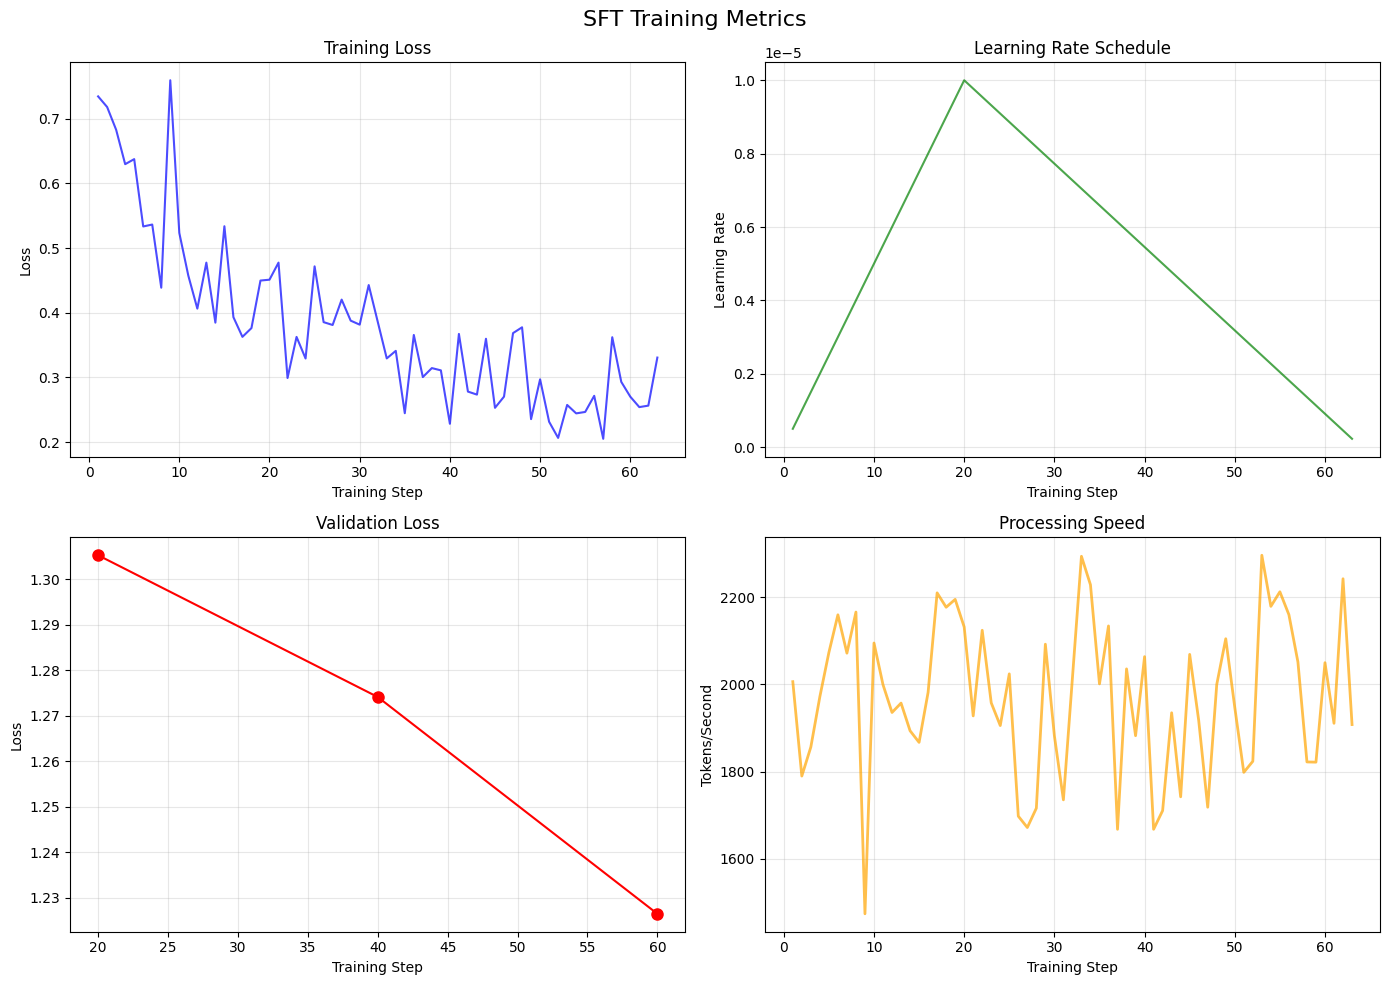


SFT TRAINING SUMMARY
Final Loss: 0.3308
Initial Loss: 0.7347
Loss Reduction: 0.4039
Average Processing Speed: 1969.8 tokens/second


In [ ]:
# Extract metrics from SFT results
sft_training_metrics = sft_results['training_metrics']
sft_validation_metrics = sft_results['validation_metrics']

# Plot SFT training metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SFT Training Metrics', fontsize=16)

# Training Loss
axes[0, 0].plot(sft_training_metrics["step"], sft_training_metrics["loss"], 'b-', alpha=0.7)
axes[0, 0].set_xlabel('Training Step')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].grid(True, alpha=0.3)

# Learning Rate
axes[0, 1].plot(sft_training_metrics["step"], sft_training_metrics["learning_rate"], 'g-', alpha=0.7)
axes[0, 1].set_xlabel('Training Step')
axes[0, 1].set_ylabel('Learning Rate')
axes[0, 1].set_title('Learning Rate Schedule')
axes[0, 1].grid(True, alpha=0.3)

# Validation Loss
if sft_validation_metrics["step"]:
    axes[1, 0].plot(sft_validation_metrics["step"], sft_validation_metrics["loss"], 
                    'ro-', markersize=8)
    axes[1, 0].set_xlabel('Training Step')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].set_title('Validation Loss')
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No validation data', ha='center', va='center')

# Tokens per Second
axes[1, 1].plot(sft_training_metrics["step"], sft_training_metrics["tokens_per_second"], 
                'orange', alpha=0.7, linewidth=2)
axes[1, 1].set_xlabel('Training Step')
axes[1, 1].set_ylabel('Tokens/Second')
axes[1, 1].set_title('Processing Speed')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print SFT summary
print("\n" + "="*60)
print("SFT TRAINING SUMMARY")
print("="*60)
print(f"Final Loss: {sft_training_metrics['loss'][-1]:.4f}")
print(f"Initial Loss: {sft_training_metrics['loss'][0]:.4f}")
print(f"Loss Reduction: {sft_training_metrics['loss'][0] - sft_training_metrics['loss'][-1]:.4f}")
print(f"Average Processing Speed: {np.mean(sft_training_metrics['tokens_per_second']):.1f} tokens/second")

In [ ]:
# MANUAL CHECKPOINT SAVE - Run this if SFT training completed but checkpoint wasn't saved
try:
    # Check if sft variable exists
    print(f"SFT model in memory: {type(sft)}")
    print(f"SFT global step: {sft.global_step}")
    
    # Save the checkpoint manually
    from pathlib import Path
    sft_checkpoint_dir = Path("checkpoints/pipeline_stages/01_after_sft")
    sft_checkpoint_dir.mkdir(parents=True, exist_ok=True)
    sft_checkpoint_path = sft_checkpoint_dir / "sft_complete.pt"
    
    sft.save_checkpoint(str(sft_checkpoint_path))
    print(f"\n✓ Successfully saved SFT checkpoint to: {sft_checkpoint_path}")
    
    # Verify it exists
    import os
    if os.path.exists(sft_checkpoint_path):
        file_size = os.path.getsize(sft_checkpoint_path) / (1024**3)  # GB
        print(f"✓ Checkpoint file exists: {file_size:.2f} GB")
    else:
        print("❌ ERROR: Checkpoint file was not created!")
        
except NameError:
    print("❌ ERROR: 'sft' variable not found in memory!")
    print("You need to re-run cell 13 (SFT Training) first.")
except Exception as e:
    print(f"❌ ERROR saving checkpoint: {e}")
    import traceback
    traceback.print_exc()

SFT model in memory: <class 'simple_rl.algorithms.sft.SFT'>
SFT global step: 64

✓ Successfully saved SFT checkpoint to: checkpoints/pipeline_stages/01_after_sft/sft_complete.pt
✓ Checkpoint file exists: 5.52 GB


## 7. Group Relative Policy Optimization (GRPO)

### 7.1 GRPO Configuration

In [ ]:
# GRPO Configuration
grpo_config = {
    "algorithm": {
        "name": "grpo",
        "group_size": 4,
        "kl_coef": 0.001,
        #"clip_epsilon": 0.2,  # For symmetric clipping (backward compatibility)
        "clip_epsilon_low": 0.2,  # Lower bound: 1 - 0.2 = 0.8
        "clip_epsilon_high": 0.4,  # Upper bound: 1 + 0.4 = 1.4
        "normalize_rewards": True,
        "store_completions": False,
    },
    "training": {
        "batch_size": 32,
        "rollout_batch_size": 2,
        "gradient_clip": 0.1,
        "max_new_tokens": 200,
        "temperature": 1.0,
        "num_episodes": 500,
        "minibatch_size": 64,
        "update_epochs": 1,
        "top_p": 1.0
    },
    "model": {
        "max_length": 1024,
        "model_name": MODEL_NAME,
        "model_type": "fp16",
        "device": str(device),
        "compile": {
            "enabled": True,
            "backend": "aot_eager"
        }
    },
    "logging": {
        "log_interval": 1,
        "save_interval": 15,  # Save every 15 episodes (25%, 50%, 75%, 100%)
    },
    "validation": {
        "enabled": True,
        "interval": 20,
        "num_samples": 20,
        "num_demo_examples": 5,
    },
    "wandb": {
        "enabled": False,
    },
    "optimizer": {
        "type": "adam",
        "lr": 5e-6,
        "weight_decay": 0.01,
        "betas": (0.9, 0.999),
        "eps": 1e-8,
        "fused": False
    },
    "optimization": {
        "mixed_precision": {
            "enabled": True,
            "dtype": "fp16",
            "mode": "fp16"
        }
    },
    "timing": {
        "enabled": False,  # Disable timing printouts
    },
    "debug": {
        "enabled": False,  # Disabled for cleaner output
        "generation": False,  # Set to True to see generation debug messages (token counts, EOS, dtype, etc.)
        "log_dir": "debug_logs"
    }
}

print("GRPO Configuration:")
print(json.dumps(grpo_config, indent=2))
print(f"\nCheckpoints will be saved at episodes: 15 (25%), 30 (50%), 45 (75%), 60 (100%)")
print(f"\n💡 Tip: Set debug.generation=True to see detailed generation statistics")
print(f"\n📊 PPO Clipping: ratio clipped to [{1-grpo_config['algorithm']['clip_epsilon_low']:.1f}, {1+grpo_config['algorithm']['clip_epsilon_high']:.1f}]")

GRPO Configuration:
{
  "algorithm": {
    "name": "grpo",
    "group_size": 4,
    "kl_coef": 0.001,
    "clip_epsilon_low": 0.2,
    "clip_epsilon_high": 0.4,
    "normalize_rewards": true,
    "store_completions": false
  },
  "training": {
    "batch_size": 32,
    "rollout_batch_size": 2,
    "gradient_clip": 0.1,
    "max_new_tokens": 200,
    "temperature": 1.0,
    "num_episodes": 500,
    "minibatch_size": 64,
    "update_epochs": 1,
    "top_p": 1.0
  },
  "model": {
    "max_length": 1024,
    "model_name": "Qwen/Qwen2.5-0.5B-Instruct",
    "model_type": "fp16",
    "device": "mps",
    "compile": {
      "enabled": true,
      "backend": "aot_eager"
    }
  },
  "logging": {
    "log_interval": 1,
    "save_interval": 15
  },
  "validation": {
    "enabled": true,
    "interval": 20,
    "num_samples": 20,
    "num_demo_examples": 5
  },
  "wandb": {
    "enabled": false
  },
  "optimizer": {
    "type": "adam",
    "lr": 5e-06,
    "weight_decay": 0.01,
    "betas": [
    

### 7.2 Initialize GRPO with SFT Checkpoint

In [ ]:
# Load SFT checkpoint and initialize GRPO with pre-loaded model
print("Loading SFT checkpoint and initializing GRPO...")
print(f"Checkpoint path: {sft_checkpoint_path}")

# Step 1: Load SFT checkpoint
sft_checkpoint = torch.load(sft_checkpoint_path, map_location=device)

# Step 2: Get model name from checkpoint
model_name = sft_checkpoint["config"]["model"]["model_name"]
print(f"Model: {model_name}")

# Step 3: Load fresh model and tokenizer
print("\nLoading fresh model and tokenizer...")
from transformers import AutoModelForCausalLM, AutoTokenizer

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float32,
    trust_remote_code=True
)
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("✓ Model and tokenizer loaded")

# Step 4: Load SFT weights into fresh model (BEFORE GRPO initialization)
print("\nLoading SFT weights into model...")
model.load_state_dict(sft_checkpoint["model_state_dict"])
print("✓ SFT weights loaded successfully")

# Step 5: Initialize GRPO with pre-loaded model
print("\nInitializing GRPO with SFT-trained model...")
grpo = GRPO(
    config=grpo_config,
    batch_reward_fn=compute_math_rewards_batch,
    model=model,
    tokenizer=tokenizer,
    use_wandb=False
)

print("\n" + "="*60)
print("✓ GRPO successfully initialized with SFT-trained model")
print("="*60)
print("The reference model has also been initialized from the SFT weights.")
print("Ready to start GRPO training!")

### 7.3 GRPO Training

In [ ]:
# Prepare data for GRPO
grpo_train_data = {
    "prompts": grpo_train_prompts,
    "answers": grpo_train_answers
}

grpo_val_data = {
    "prompts": grpo_val_prompts,
    "answers": grpo_val_answers
}

print("\n" + "="*60)
print("STARTING GRPO TRAINING")
print("="*60)

# Train GRPO
grpo_results = grpo.train(
    train_data=grpo_train_data,
    val_data=grpo_val_data,
    num_episodes=grpo_config['training']['num_episodes']
)

print("\n" + "="*60)
print("GRPO TRAINING COMPLETE")
print("="*60)
print(f"Total time: {grpo_results['total_time']:.2f} seconds ({grpo_results['total_time']/60:.2f} minutes)")
print(f"Total tokens processed: {grpo_results['training_metrics']['total_tokens'][-1]:,}")
print(f"Final reward: {grpo_results['final_reward']:.3f}")

# Organize GRPO checkpoints into pipeline stages folder
import shutil

print("\n" + "="*60)
print("ORGANIZING GRPO CHECKPOINTS")
print("="*60)

# Create pipeline stages directories
grpo_checkpoints = [
    (15, "02_grpo_25_percent"),
    (30, "03_grpo_50_percent"),
    (45, "04_grpo_75_percent"),
    (60, "05_grpo_100_percent")
]

source_checkpoint_dir = Path("checkpoints/grpo_qwen_math")
pipeline_stages_dir = Path("checkpoints/pipeline_stages")

for episode, stage_name in grpo_checkpoints:
    source_path = source_checkpoint_dir / f"checkpoint_episode_{episode}.pt"
    dest_dir = pipeline_stages_dir / stage_name
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest_path = dest_dir / f"grpo_{episode}_episodes.pt"
    
    if source_path.exists():
        shutil.copy2(source_path, dest_path)
        print(f"✓ Copied episode {episode} → {dest_path}")
    else:
        print(f"⚠ Warning: {source_path} not found")

print("\n" + "="*60)
print("CHECKPOINT ORGANIZATION COMPLETE")
print("="*60)
print(f"\nAll checkpoints saved in: checkpoints/pipeline_stages/")
print(f"  00_base_model/         - Base model (before training)")
print(f"  01_after_sft/          - After SFT completion")
print(f"  02_grpo_25_percent/    - GRPO at 25% (15 episodes)")
print(f"  03_grpo_50_percent/    - GRPO at 50% (30 episodes)")
print(f"  04_grpo_75_percent/    - GRPO at 75% (45 episodes)")
print(f"  05_grpo_100_percent/   - GRPO at 100% (60 episodes)")


STARTING GRPO TRAINING
Starting proper GRPO training for 500 episodes...
  - Using PPO clipped objective (asymmetric: low=0.2, high=0.4)
    Ratio clipped to [0.80, 1.40]
  - Training samples: 6973
  - Batch size: 32
  - Update epochs: 1
  - Group size: 4
  - Rollout batch size: 2 prompts (OOM prevention)
  - Minibatch size: 64 rollouts per update
  - Validation enabled: every 20 episodes
    - Evaluating 20 validation samples
    - Showing 5 demo examples
Episode   0 | Loss:  0.1081 | PG Loss:  0.1081 | KL:  0.0076 | Reward:  0.245 ± 0.377 | Fmt: 0.163 | Correct: 0.082 | Tokens: 25483 | Time: 191.75s | Speed:  132.9 tok/s
Episode   1 | Loss:  0.0573 | PG Loss:  0.0573 | KL:  0.0414 | Reward:  0.294 ± 0.347 | Fmt: 0.223 | Correct: 0.070 | Tokens: 24293 | Time: 158.31s | Speed:  153.5 tok/s
Episode   2 | Loss:  0.0531 | PG Loss:  0.0530 | KL:  0.0920 | Reward:  0.358 ± 0.443 | Fmt: 0.241 | Correct: 0.117 | Tokens: 24996 | Time: 152.00s | Speed:  164.5 tok/s
Episode   3 | Loss:  0.0749 

Generating: 100%|██████████| 20/20 [01:21<00:00,  4.09s/it]


Evaluating responses...


Evaluating: 100%|██████████| 20/20 [00:00<00:00, 43374.40it/s]



Episode 20 Evaluation Results:
  Exact Match Accuracy: 20.0%
  Numeric Accuracy: 0.0%
  Format Compliance: 100.0%
  Avg Format Score: 0.800
  Avg Correctness Score: 0.400

EPISODE 20 RESPONSE EXAMPLES

Example 1:
Problem: Respond in the following format:

<reasoning>
...
</reasoning>
<answer>
...
</answer>
Carl’s favorite food is cheese. He ate a sandwich every day this...
Correct Answer: 31
----------------------------------------
Model Response:
<reasoning>
First, Carl ate cheese sandwiches on a daily basis for a week, which totals 7 sandwiches.

He then ate eggs for breakfast for 3 days, which means he used 3 slices of eggs.

To find out how much cheese Carl used, we need to figure out how much was eaten by the sandwiches. Since he ate 2 slices on each sandwich, we multiply the number of sandwiches by the slices per sandwich: 7 sandwiches * 2 slices/sandwich = 14 slices.

Finally, we add the slices from the sandwiches and the eggs to get the total cheese used: 14 slices + 3 slices 

...

Generating: 100%|██████████| 20/20 [01:12<00:00,  3.61s/it]


Evaluating responses...


Evaluating: 100%|██████████| 20/20 [00:00<00:00, 33380.85it/s]



Episode 280 Evaluation Results:
  Exact Match Accuracy: 0.0%
  Numeric Accuracy: 0.0%
  Format Compliance: 95.0%
  Avg Format Score: 0.790
  Avg Correctness Score: 0.075

EPISODE 280 RESPONSE EXAMPLES

Example 1:
Problem: Respond in the following format:

<reasoning>
...
</reasoning>
<answer>
...
</answer>
Carl’s favorite food is cheese. He ate a sandwich every day this...
Correct Answer: 31
----------------------------------------
Model Response:
<reasoning>
 The 3 sandwiches used 2 slices of cheese, which 3 days of omelets used 8 slices of cheese. 8 slices of cheese did he use 8. 
</reasoning>
<answer>
 8 slices of cheese did he use. 
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>48 slices of cheese did he use.
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</answer>
</a

KeyboardInterrupt: 

### 7.4 GRPO Evaluation

In [ ]:
print("\n" + "="*60)
print("GRPO MODEL EVALUATION")
print("="*60)

# Evaluate GRPO model
grpo_metrics = evaluate_on_gsm8k(
    grpo,
    grpo_test_prompts,
    grpo_test_answers,
    len(grpo_test_prompts),
    model_name="GRPO Model (After RL Training)",
    save_results=True,
    results_file="results/grpo_eval_results.json",
    step=grpo_config["training"]["num_episodes"]
)

# Show examples
demonstrate_model_responses(
    grpo,
    grpo_test_prompts,
    grpo_test_answers,
    5,
    title="GRPO MODEL EXAMPLES (After RL Training)"
)

### 7.5 GRPO Visualization

In [ ]:
# Extract metrics from GRPO results
grpo_training_metrics = grpo_results['training_metrics']
grpo_validation_metrics = grpo_results['validation_metrics']

# Plot GRPO training and validation metrics
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('GRPO Training and Validation Metrics', fontsize=16)

# Total Loss
axes[0, 0].plot(grpo_training_metrics["episode"], grpo_training_metrics["total_loss"], 'b-', alpha=0.7)
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Total Loss over Training')
axes[0, 0].grid(True, alpha=0.3)

# Mean Reward
axes[0, 1].plot(grpo_training_metrics["episode"], grpo_training_metrics["reward_mean"], 'purple', alpha=0.7, label='Mean')
axes[0, 1].fill_between(
    grpo_training_metrics["episode"],
    np.array(grpo_training_metrics["reward_mean"]) - np.array(grpo_training_metrics["reward_std"]),
    np.array(grpo_training_metrics["reward_mean"]) + np.array(grpo_training_metrics["reward_std"]),
    alpha=0.3, color='purple'
)
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Reward')
axes[0, 1].set_title('Mean Reward ± Std')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# KL Divergence
axes[1, 0].plot(grpo_training_metrics["episode"], grpo_training_metrics["kl_divergence"], 'r-', alpha=0.7)
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('KL Divergence')
axes[1, 0].set_title('KL Divergence from Reference')
axes[1, 0].grid(True, alpha=0.3)

# Validation Accuracy
if grpo_validation_metrics["episode"]:
    axes[1, 1].plot(grpo_validation_metrics["episode"], grpo_validation_metrics["exact_accuracy"], 
                    'go-', label='Exact Match', markersize=8)
    axes[1, 1].plot(grpo_validation_metrics["episode"], grpo_validation_metrics["numeric_accuracy"], 
                    'bs-', label='Numeric Match', markersize=8)
    axes[1, 1].set_xlabel('Episode')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].set_title('Validation Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No validation data', ha='center', va='center')

# Format Compliance
if grpo_validation_metrics["episode"]:
    axes[2, 0].plot(grpo_validation_metrics["episode"], grpo_validation_metrics["format_compliance"], 
                    'mo-', label='Format Compliance %', markersize=8)
    axes[2, 0].set_xlabel('Episode')
    axes[2, 0].set_ylabel('Compliance (%)')
    axes[2, 0].set_title('Format Compliance')
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)
else:
    axes[2, 0].text(0.5, 0.5, 'No validation data', ha='center', va='center')

# Episode Time
axes[2, 1].plot(grpo_training_metrics["episode"], grpo_training_metrics["episode_time"], 
                'orange', alpha=0.7, linewidth=2)
axes[2, 1].set_xlabel('Episode')
axes[2, 1].set_ylabel('Time (seconds)')
axes[2, 1].set_title('Episode Training Time')
axes[2, 1].grid(True, alpha=0.3)

# Cumulative Tokens Processed
axes[3, 0].plot(grpo_training_metrics["episode"], 
                [t/1000 for t in grpo_training_metrics["total_tokens"]], 
                'green', alpha=0.7, linewidth=2)
axes[3, 0].set_xlabel('Episode')
axes[3, 0].set_ylabel('Tokens (thousands)')
axes[3, 0].set_title('Cumulative Tokens Processed')
axes[3, 0].grid(True, alpha=0.3)

# Processing Speed
axes[3, 1].plot(grpo_training_metrics["episode"], grpo_training_metrics["tokens_per_second"], 
                'darkblue', alpha=0.7, linewidth=2)
axes[3, 1].set_xlabel('Episode')
axes[3, 1].set_ylabel('Tokens/Second')
axes[3, 1].set_title('Token Processing Speed')
axes[3, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print GRPO summary
print("\n" + "="*60)
print("GRPO TRAINING SUMMARY")
print("="*60)
print(f"Final Total Loss: {grpo_training_metrics['total_loss'][-1]:.4f}")
print(f"Final KL Divergence: {grpo_training_metrics['kl_divergence'][-1]:.4f}")
print(f"Final Mean Reward: {grpo_training_metrics['reward_mean'][-1]:.3f}")
print(f"Average Reward (last 5 episodes): {np.mean(grpo_training_metrics['reward_mean'][-5:]):.3f}")
print(f"Total Tokens Processed: {grpo_training_metrics['total_tokens'][-1]:,}")
print(f"Average Processing Speed: {np.mean(grpo_training_metrics['tokens_per_second']):.1f} tokens/second")

NameError: name 'grpo_results' is not defined

## 8. Final Comparison: Base vs SFT vs GRPO

In [ ]:
# Compare all three models
print("\n" + "="*80)
print("FINAL COMPARISON: BASE MODEL vs SFT vs GRPO")
print("="*80)

comparison_data = {
    'Model': ['Base (Before Training)', 'SFT (After Supervised)', 'GRPO (After RL)'],
    'Exact Accuracy': [
        f"{base_metrics['exact_accuracy']:.1f}%",
        f"{sft_metrics['exact_accuracy']:.1f}%",
        f"{grpo_metrics['exact_accuracy']:.1f}%"
    ],
    'Numeric Accuracy': [
        f"{base_metrics['numeric_accuracy']:.1f}%",
        f"{sft_metrics['numeric_accuracy']:.1f}%",
        f"{grpo_metrics['numeric_accuracy']:.1f}%"
    ],
    'Format Compliance': [
        f"{base_metrics['format_compliance']:.1f}%",
        f"{sft_metrics['format_compliance']:.1f}%",
        f"{grpo_metrics['format_compliance']:.1f}%"
    ],
    'Avg Format Score': [
        f"{base_metrics['avg_format_score']:.3f}",
        f"{sft_metrics['avg_format_score']:.3f}",
        f"{grpo_metrics['avg_format_score']:.3f}"
    ],
    'Avg Correctness': [
        f"{base_metrics['avg_correctness_score']:.3f}",
        f"{sft_metrics['avg_correctness_score']:.3f}",
        f"{grpo_metrics['avg_correctness_score']:.3f}"
    ]
}

# Print table
print(f"\n{'Model':<30} {'Exact Acc':<12} {'Numeric Acc':<12} {'Format':<12} {'Fmt Score':<12} {'Correct':<12}")
print("-" * 90)
for i in range(3):
    print(f"{comparison_data['Model'][i]:<30} "
          f"{comparison_data['Exact Accuracy'][i]:<12} "
          f"{comparison_data['Numeric Accuracy'][i]:<12} "
          f"{comparison_data['Format Compliance'][i]:<12} "
          f"{comparison_data['Avg Format Score'][i]:<12} "
          f"{comparison_data['Avg Correctness'][i]:<12}")

# Calculate improvements
print("\n" + "="*80)
print("IMPROVEMENTS")
print("="*80)
print(f"\nBase → SFT:")
print(f"  Exact Accuracy: {sft_metrics['exact_accuracy'] - base_metrics['exact_accuracy']:+.1f}%")
print(f"  Format Compliance: {sft_metrics['format_compliance'] - base_metrics['format_compliance']:+.1f}%")
print(f"  Correctness Score: {sft_metrics['avg_correctness_score'] - base_metrics['avg_correctness_score']:+.3f}")

print(f"\nSFT → GRPO:")
print(f"  Exact Accuracy: {grpo_metrics['exact_accuracy'] - sft_metrics['exact_accuracy']:+.1f}%")
print(f"  Format Compliance: {grpo_metrics['format_compliance'] - sft_metrics['format_compliance']:+.1f}%")
print(f"  Correctness Score: {grpo_metrics['avg_correctness_score'] - sft_metrics['avg_correctness_score']:+.3f}")

print(f"\nBase → GRPO (Total):")
print(f"  Exact Accuracy: {grpo_metrics['exact_accuracy'] - base_metrics['exact_accuracy']:+.1f}%")
print(f"  Format Compliance: {grpo_metrics['format_compliance'] - base_metrics['format_compliance']:+.1f}%")
print(f"  Correctness Score: {grpo_metrics['avg_correctness_score'] - base_metrics['avg_correctness_score']:+.3f}")

print("\n" + "="*80)
print("FULL PIPELINE COMPLETE")
print("="*80)
print(f"\nTraining Configuration:")
print(f"  SFT Training: 200 examples (train[:200])")
print(f"  GRPO Training: 200 examples (train[200:400]) - NO OVERLAP")
print(f"  Validation: 1000 examples (same for both)")
print(f"  Test: 200 examples (same for both)")
print(f"\nTraining Time:")
print(f"  SFT Training: {sft_results['total_time']/60:.2f} minutes")
print(f"  GRPO Training: {grpo_results['total_time']/60:.2f} minutes")
print(f"  Total Training: {(sft_results['total_time'] + grpo_results['total_time'])/60:.2f} minutes")